# 6 Transmission planning and expansion

Transmission is no longer just infrastructure—it serves as a key flexibility lever for
integrating variable renewables at scale.

• Effective planning must co-optimize generation, storage, and transmission, rather than treat them as isolated or sequential processes.

• The value of a transmission corridor lies not merely in its capacity, but in its ability
to unlock cheaper generation, reduce curtailment, and balance spatial mismatches.

• Trade-offs between spatial (transmission) and temporal (storage) flexibility are highly
system-dependent and should be evaluated under realistic cost and policy
constraints.

• PyPSA enables transparent, reproducible modeling of expansion decisions under
user-defined emissions, cost, and infrastructure limits.

• A cost-optimal network is not necessarily robust, but it provides the benchmark
against which system resilience and redundancy can be assessed

This notebook focuses on the principles and methods of long-term transmis­sion expansion planning. While a full regulatory or operational treatment is beyond scope, the chapter aims to present the technical and economic rationale
for expansion, introduce the modeling capabilities of PyPSA for this purpose, and demonstrate their application through a simplified yet illustrative case study.

The emphasis is on open, reproducible modeling techniques that align with the needs of power system researchers, analysts, and planners engaged in decar­bonization pathways.

Transmission corridors are predefined geographical routes reserved or developed
for high-voltage transmission lines. Rather than considering isolated lines, cor­
ridors group parallel paths that often share infrastructure or legal right-of-way. In
expansion planning, modeling at the corridor level helps simplify spatial decision­
making, reduce environmental conflict, and account for economies of scale in
future grid reinforcement.

At the core, transmission system consists of nodes/buses, lines or links/edges, generators, loads, transformers, and storage units

Cost-Benefit Analysis (CBA) is a structured approach used to evaluate infrastruc­
ture projects by comparing the projected benefits to their total costs. In the context
of power grids, benefits may include reduced curtailment, improved reliability,
and lower operational costs, while costs cover capital investment and environ­
mental impact. CBA helps prioritize transmission projects that offer the greatest
net value and informs strategic decisions in regional or national planning frame­
works.

Transmission in PYPSA such as AC lines, and DC links or transformers can be modelled as build_extendable=True

# Planning Renewable Transmission Corridor Between NorthGrid and SouthGrid

This case study explores how a cost-optimal transmission corridor can emerge
from a clean-slate power-system planning exercise using PyPSA. I consider
a greenfield system composed of two spatially distinct regions-NorthGrid (Northern Regions)
and SouthGrid-with complementary roles. NorthGrid is endowed with high­
quality wind and solar resources and has potential for battery storage, 
 The PyPSA Handbook
SouthGrid (Southern Parts of Ghana) serves as the main demand center, supported only by a dispatchable
backup gas generator

Starts from  
- temporal resolution
- Network layout
- Renewable availability
- Demand profiles
- Storage
- Transmission global constraints

In [109]:
import pypsa
import pandas as pd
import numpy as np

In [110]:
# Initializing Pypsa network with one week hourly snapshots

network = pypsa.Network()
snapshots = pd.date_range("2025-01-01 00:00", periods=168, freq="h")
network.set_snapshots(snapshots)

In [111]:
# Buses (refers to an electrically connected point - a place where things meet)

buses = [
    "NorthWind",
    "NorthSolar",
    "NorthStorage",
    "NorthHub",
    "SouthHub",
    "SouthLoad",
    "SouthBackupGen",
]

for b in buses:
    network.add("Bus", b)

bus_coords = {
    "NorthWind": (10.0, 56.0),
    "NorthSolar": (11.0, 56.1),
    "NorthStorage": (10.5, 55.8),
    "NorthHub": (10.5, 55.5),
    "SouthHub": (10.5, 54.5),
    "SouthLoad": (10.3, 54.2),
    "SouthBackupGen": (10.7, 54.1),
}

for bus, (x, y) in bus_coords.items():
    network.buses.at[bus, "x"] = x
    network.buses.at[bus, "y"] = y

In [112]:
network

PyPSA Network 'Unnamed Network'
-------------------------------
Components:
 - Bus: 7
Snapshots: 168

In [113]:
# Load Demand Profile Designed Using a Sinusoidal Profile
load_profile = pd.Series(
    300 + 60 * np.sin(np.linspace(0, 3 * np.pi, 168)), index=snapshots
)

network.add("Load", "SouthDemand", bus="SouthLoad", p_set=load_profile)

In [114]:
# Renewable Generation and Storage Configuration
np.random.seed(0)

wind_profile = pd.Series(
    np.clip(np.random.normal(0.6, 0.2, 168), 0, 1), index=snapshots
)

wind_profile[60:70] = 0.2  # simulating wind lull (between hours 60-69)
# Generates numbers centered around 0.6, 60% with std of 0.2 but occasionally falls below/above 0, 1 then gets cut


solar_profile = pd.Series(
    [
        max(0, np.sin(np.pi * (h % 24 - 6) / 12)) if 6 <= (h % 24) <= 18 else 0
        for h in range(168)
    ],
    index=snapshots,
)

In [115]:
# Addition of Power Generators
network.add(
    "Generator",
    "WindNorth",
    bus="NorthWind",
    p_nom_extendable=True,
    p_max_pu=wind_profile,
    capital_cost=800,
    marginal_cost=0,
)


network.add(
    "Generator",
    "SolarNorth",
    bus="NorthSolar",
    p_nom_extendable=True,
    p_max_pu=solar_profile,
    capital_cost=200,
    marginal_cost=0,
)


network.add(
    "Generator",
    "GasSouth",
    bus="SouthBackupGen",
    p_nom_extendable=True,
    capital_cost=600,
    marginal_cost=70,
    carrier="gas",
)

In [116]:
# Storage (battery unit) at the north for temporal flexibility
network.add(
    "StorageUnit",
    "Battery_North",
    bus="NorthStorage",
    p_nom_extendable=True,
    max_hours=4,
    efficiency_store=0.9,
    efficiency_dispatch=0.9,
    capital_cost=200,
    marginal_cost=0.01,
)

In [117]:
# Transmission configuration: Internal links and corridor alternatives
internal_links = [
    ("NorthWind", "NorthHub"),
    ("NorthSolar", "NorthHub"),
    ("NorthStorage", "NorthHub"),
    ("SouthHub", "SouthLoad"),
    ("SouthBackupGen", "SouthHub"),
]

# Link you control power flow
for a, b in internal_links:
    network.add("Link", f"{a}_to_{b}", bus0=a, bus1=b, p_nom=1000, efficiency=1.0)

Adding two extendable interregional corridors with different capital
costs to connect NorthHub(Northern Region) and SouthHub (South Region)

In [118]:
# Region connected via parallel transmission corridors - Corridors A and B both linking NorthHub to SouthHub
network.add(
    "Link",
    "Corridor_A",
    bus0="NorthHub",
    bus1="SouthHub",
    p_nom_extendable=True,
    efficiency=1.0,
    capital_cost=200,
    carrier="AC",
)

network.add(
    "Link",
    "Corridor_B",
    bus0="NorthHub",
    bus1="SouthHub",
    p_nom_extendable=True,
    efficiency=1.0,
    capital_cost=150,
    carrier="AC",
)

To reflect realistic planning constraints, a GLOBAL LIMIT is imposed on the total
volume of transmission capacity that can be built across both corridors. This
constraint forces the model to prioritize one corridor over the other or divide
expansion between them, based on cost-effectiveness and system-wide benefit.

In [119]:
network.add(
    "GlobalConstraint",
    "max_corridor_expansion",
    type="transmission_volume_expansion_limit",
    carrier_attribute="carrier",
    sense="<=",
    constant=200,
)

Emission Constraint and Model Optimization
- Enforcing decarbonization policy contraints
- Cap on CO2 is placed on the system, which would affect the gas and then force the model to align more towards the renewable energy generators


"Gas emits 0.2t CO2 per MWh. Across all hours and all gas generators in this network, total CO2 must not exceed 10,000 tonnes."

In [120]:
network.add("Carrier", "gas", co2_emissions=0.2)

network.add(
    "GlobalConstraint",
    "co2_limit",
    type="primary_energy_cap",
    carrier_attribute="co2_emissions",
    sense="<=",
    constant=10_000,
)

Setting keep_shadowprices=True ensures that
PyPSA retains dual variables (also called shadow prices) from the linear pro­gram. 

These values are essential for interpreting the marginal cost of supplying
energy at each bus (nodal prices), identifying congestion, and understanding which constraints are binding.

 This is particularly useful for post-optimization
analysis and visualization of economic indicators such as scarcity pricing or curtailment conditions. Without keep_shadowprices=True, PyPSA discards the
dual variables after solving the optimization problem. 

As a result, post-analysis metrics such as marginal prices, congestion rents, and binding constraint diag­nostics would not be available for interpretation or plotting.


PyPSA has two optimisation backends:
1. Native (default in newer PyPSA)
PyPSA builds the optimisation problem itself using linopt — its own internal framework. Faster, leaner, but less flexible.
2. Pyomo
An external Python optimisation modelling library. More flexible, supports more solver types, and critically  enables shadow prices to be retrieved properly.

In [121]:
network.optimize(solver_name="highs", assign_all_duals=True)

/tmp/ipykernel_23368/2342787558.py:1: FutureWarning: The default value of `include_objective_constant` will change from True to False in version 2.0. Set `include_objective_constant` explicitly to suppress this warning. Using False improves LP numerical conditioning by not including the objective constant as a variable.
  network.optimize(solver_name="highs",
Index(['NorthWind', 'NorthSolar', 'NorthStorage', 'NorthHub', 'SouthHub',
       'SouthLoad', 'SouthBackupGen'],
      dtype='str', name='name')
Index(['NorthWind_to_NorthHub', 'NorthSolar_to_NorthHub',
       'NorthStorage_to_NorthHub', 'SouthHub_to_SouthLoad',
       'SouthBackupGen_to_SouthHub', 'Corridor_A', 'Corridor_B'],
      dtype='str', name='name')
INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io: Writing time: 0.14s
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 2190 primals, 5718 duals
Objective: 1.00e+06
Solver model: available
Solver message: Opt

Running HiGHS 1.14.0 (git hash: 7df0786): Copyright (c) 2026 under MIT licence terms
LP linopy-problem-reu1ym7d has 5718 rows; 2190 cols; 9490 nonzeros
Coefficient ranges:
  Matrix  [9e-02, 4e+00]
  Cost    [1e-02, 8e+02]
  Bound   [0e+00, 0e+00]
  RHS     [2e+02, 1e+03]
Presolving model
1925 rows, 1427 cols, 4934 nonzeros 0s
Dependent equations search running on 336 equations with time limit of 1000.00s
Dependent equations search removed 0 rows and 0 nonzeros in 0.00s (limit = 1000.00s)
1085 rows, 754 cols, 2583 nonzeros 0s
Presolve reductions: rows 1085(-4633); columns 754(-1436); nonzeros 2583(-6907) 
Solving the presolved LP
Using dual simplex solver
  Iteration        Objective     Infeasibilities num(sum)
          0     0.0000000000e+00 Pr: 168(52525.7) 0.1s
        635     1.0026143005e+06 Pr: 0(0) 0.1s

Performed postsolve
Solving the original LP from the solution after postsolve

Model name          : linopy-problem-reu1ym7d
Model status        : Optimal
Simplex   iterations:

('ok', 'optimal')

But you still want shadow prices?
In newer PyPSA with linopy, shadow prices are retrieved differently:

In [122]:
# C02 shadow prices
network.global_constraints.mu

name
max_corridor_expansion    0.0
co2_limit                 0.0
Name: mu, dtype: float64

In [123]:
# See how much gas was actually dispatched
gen_t = network.generators_t.p

# Calculate actual CO2
gas_gens = network.generators[network.generators.carrier == "gas"].index
gas_dispatch = gen_t[gas_gens].sum().sum()  # total MWh
actual_co2 = gas_dispatch * 0.2
print(f"Actual CO2: {actual_co2:.1f} tonnes")
print(f"CO2 limit:  10_000 tonnes")

Actual CO2: 566.6 tonnes
CO2 limit:  10_000 tonnes


Shows how northern renewables serve southern load, the role of battery storage, and where gas fills gaps.

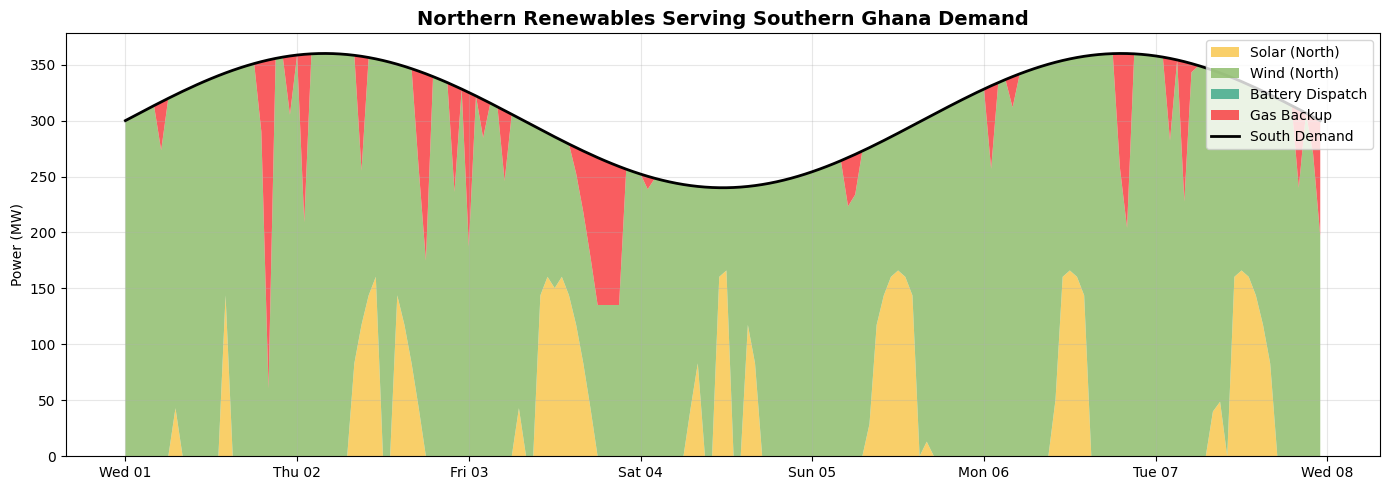

In [124]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

fig, ax = plt.subplots(figsize=(14, 5))

# Generation sources
solar_gen = network.generators_t.p["SolarNorth"]
wind_gen = network.generators_t.p["WindNorth"]
gas_gen = network.generators_t.p["GasSouth"]
battery_dispatch = network.storage_units_t.p["Battery_North"]
demand = network.loads_t.p_set["SouthDemand"]

ax.stackplot(
    snapshots,
    solar_gen,
    wind_gen,
    battery_dispatch.clip(lower=0),
    gas_gen,
    labels=["Solar (North)", "Wind (North)", "Battery Dispatch", "Gas Backup"],
    colors=["#f9c74f", "#90be6d", "#43aa8b", "#f94144"],
    alpha=0.85,
)

ax.plot(snapshots, demand, color="black", linewidth=2, label="South Demand")
ax.set_title(
    "Northern Renewables Serving Southern Ghana Demand", fontsize=14, fontweight="bold"
)
ax.set_ylabel("Power (MW)")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%a %d"))
ax.legend(loc="upper right")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("chart1_dispatch_stack.png", dpi=150)
plt.show()

Shows which corridor carries power when, and how the optimizer splits transmission capacity - the key result of your planning model.

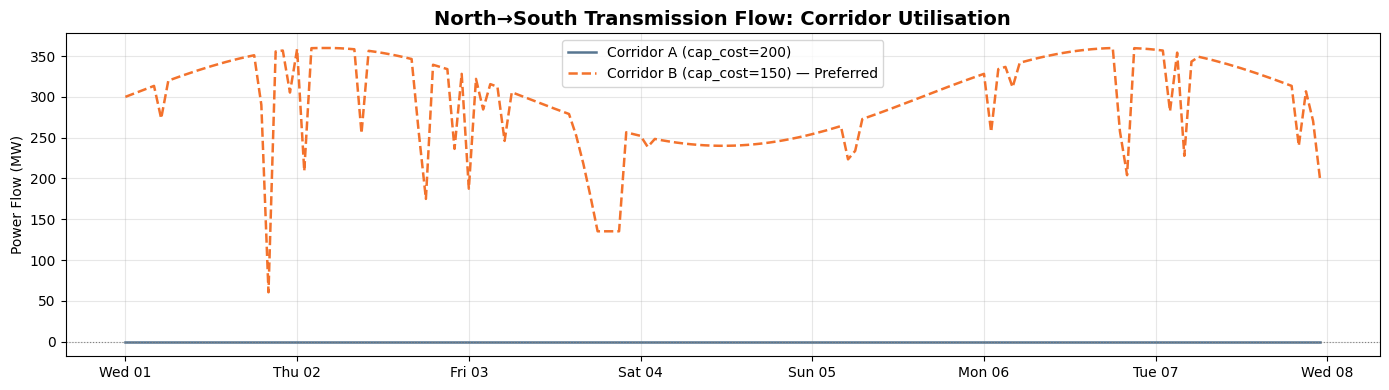

In [125]:
fig, ax = plt.subplots(figsize=(14, 4))

corridor_a = network.links_t.p0["Corridor_A"]
corridor_b = network.links_t.p0["Corridor_B"]

ax.plot(
    snapshots,
    corridor_a,
    label="Corridor A (cap_cost=200)",
    color="#577590",
    linewidth=1.8,
)
ax.plot(
    snapshots,
    corridor_b,
    label="Corridor B (cap_cost=150) — Preferred",
    color="#f3722c",
    linewidth=1.8,
    linestyle="--",
)
ax.axhline(0, color="gray", linewidth=0.8, linestyle=":")
ax.set_title(
    "North→South Transmission Flow: Corridor Utilisation",
    fontsize=14,
    fontweight="bold",
)
ax.set_ylabel("Power Flow (MW)")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%a %d"))
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("chart2_corridor_flow.png", dpi=150)
plt.show()

The headline result - what capacities the model chose to build. Clean, shareable, instantly readable.

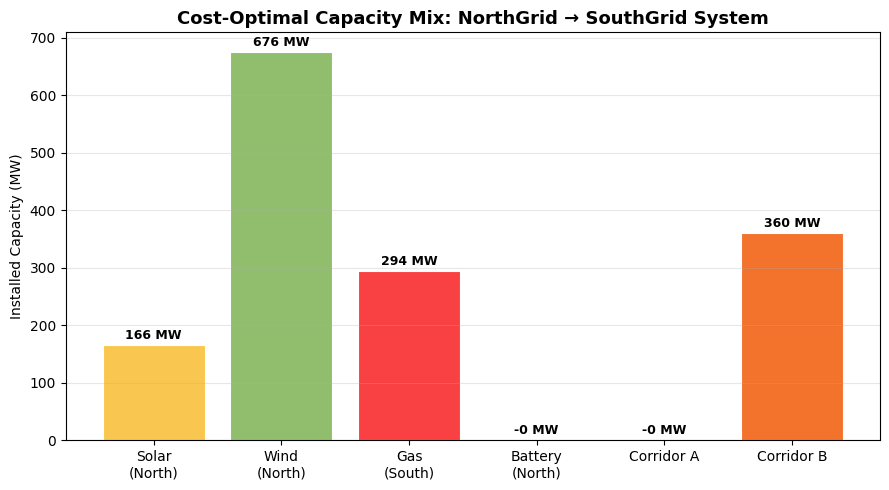

In [126]:
fig, ax = plt.subplots(figsize=(9, 5))

components = {
    "Solar\n(North)": network.generators.at["SolarNorth", "p_nom_opt"],
    "Wind\n(North)": network.generators.at["WindNorth", "p_nom_opt"],
    "Gas\n(South)": network.generators.at["GasSouth", "p_nom_opt"],
    "Battery\n(North)": network.storage_units.at["Battery_North", "p_nom_opt"],
    "Corridor A": network.links.at["Corridor_A", "p_nom_opt"],
    "Corridor B": network.links.at["Corridor_B", "p_nom_opt"],
}

colors = ["#f9c74f", "#90be6d", "#f94144", "#43aa8b", "#577590", "#f3722c"]
bars = ax.bar(
    components.keys(),
    components.values(),
    color=colors,
    edgecolor="white",
    linewidth=0.8,
)

for bar, val in zip(bars, components.values()):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 5,
        f"{val:.0f} MW",
        ha="center",
        va="bottom",
        fontsize=9,
        fontweight="bold",
    )

ax.set_title(
    "Cost-Optimal Capacity Mix: NorthGrid → SouthGrid System",
    fontsize=13,
    fontweight="bold",
)
ax.set_ylabel("Installed Capacity (MW)")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("chart3_capacity_mix.png", dpi=150)
plt.show()